# 기둥 마커 기반 침수 깊이 측정 (cm 단위)

신호등 기둥에 칠해진 흰 띠를 **자(ruler)** 로 삼아, 수면이 기둥에 닿은 높이를 cm로 환산합니다.
차량이 프레임에 없을 때의 대체 수심 추정 경로로 사용합니다.

### 물리 규격 (도로면 = 0cm 기준)

```
       ┌───┐
       │▓▓▓│ ← 흰 띠 5cm      ... 반복 (주기 10cm)
       │   │ ← 간격 5cm
       │▓▓▓│ ← 흰 띠 5cm  (49~54cm)
       │   │ ← 간격 5cm  (44~49cm)
       │▓▓▓│ ← 흰 띠 5cm  (39~44cm)  ← 첫 번째 띠
       ├───┤ 39cm
       │███│ ← 밑둥 25cm
       ├───┤ 14cm
       │███│ ← 연석 14cm
       └───┘ 0cm = 도로면
```

### 처리 흐름
1. **레퍼런스(맑은 날) 프레임**에서 흰 띠 위치를 밝기 프로파일로 자동 검출
2. 검출된 띠에 규격상 높이(41.5 / 51.5 / 61.5 … cm)를 부여 → `y픽셀 ↔ cm` 매핑 생성
3. 침수 프레임을 레퍼런스에 **호모그래피 정합** (해상도·프레이밍이 달라도 대응)
4. 수면 세그멘테이션 모델로 물 마스크 추출 → 기둥 x구간의 수면 최상단 y
5. 매핑을 적용해 **침수 깊이(cm)** 산출

> 검증 결과: 흰 띠 8개 자동 검출, 규격 대비 **최대 오차 0.7cm**, 밑둥 상단 예측 위치가 실측과 1.5px 이내 일치.

## 1. 규격 및 유틸

In [1]:
import os, json, math
from pathlib import Path

import numpy as np
import cv2
import matplotlib.pyplot as plt

In [2]:
# ──────────────────────────────────────────────────────────────
# 물리 규격: 아래에서부터 연석 14cm → 밑둥 25cm → (흰띠 5cm + 간격 5cm) 반복
# ──────────────────────────────────────────────────────────────
SPEC = {
    "curb_cm": 14.0,     # 연석
    "base_cm": 25.0,     # 밑둥
    "band_cm": 5.0,      # 흰 띠 두께
    "gap_cm": 5.0,       # 띠 사이 간격
}


def band_heights_cm(n_bands, spec=SPEC):
    """i번째(아래에서부터 0) 흰 띠의 중심 높이(cm). 도로면=0 기준."""
    start = spec["curb_cm"] + spec["base_cm"]          # 첫 띠 하단 = 39cm
    period = spec["band_cm"] + spec["gap_cm"]          # 10cm
    return [start + i * period + spec["band_cm"] / 2 for i in range(n_bands)]

## 2. 흰 띠 자동 검출

기둥 ROI 안에서 **행 평균 밝기**를 구하면 띠 주기(5cm 흰색 + 5cm 간격)가 톱니 파형으로 나타납니다.
그 봉우리가 띠 중심입니다.

연석 반사, 밑둥 하이라이트 같은 가짜 봉우리를 제거하기 위해 **등간격성(periodicity) 필터**를 반복 적용합니다.
이 필터가 없으면 가짜 띠가 하나 섞이면서 전체 눈금이 10cm씩 밀립니다.

In [3]:
def detect_bands(img, roi, smooth=3, min_prom=12.0):
    """
    기둥 ROI 안에서 흰 띠의 중심 y좌표를 밝기 프로파일로 자동 검출.
    roi = (x1, y1, x2, y2)
    return: 위→아래 순으로 정렬된 y 리스트
    """
    x1, y1, x2, y2 = roi
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32)
    prof = gray[y1:y2, x1:x2].mean(axis=1)

    if smooth > 1:
        k = np.ones(smooth) / smooth
        prof = np.convolve(prof, k, mode="same")

    peaks = []
    for i in range(1, len(prof) - 1):
        if prof[i] >= prof[i - 1] and prof[i] > prof[i + 1]:
            # 좌우로 내려가는 폭(prominence) 계산
            l = i
            while l > 0 and prof[l - 1] <= prof[l]:
                l -= 1
            r = i
            while r < len(prof) - 1 and prof[r + 1] <= prof[r]:
                r += 1
            prom = prof[i] - max(prof[l], prof[r])
            if prom >= min_prom:
                peaks.append((i, prof[i], prom))

    # 같은 봉우리 중복 제거 (5px 이내면 밝은 쪽만)
    peaks.sort(key=lambda p: p[0])
    merged = []
    for p in peaks:
        if merged and p[0] - merged[-1][0] < 5:
            if p[1] > merged[-1][1]:
                merged[-1] = p
        else:
            merged.append(p)

    ys = [y1 + p[0] for p in merged]
    # 주기 필터를 수렴할 때까지 반복 (첫 median이 이상치에 끌려가는 것 방지)
    for _ in range(4):
        new = _keep_periodic(ys, tol=0.15)
        if new == ys:
            break
        ys = new
    return ys


def _keep_periodic(ys, tol=0.28):
    """
    등간격(띠+간격 = 일정 주기)인 최장 구간만 남긴다.
    연석·지면 반사처럼 주기에서 벗어난 밝은 지점을 걸러내는 역할.
    """
    if len(ys) < 3:
        return ys
    ys = sorted(ys)
    diffs = np.diff(ys)
    med = float(np.median(diffs))
    if med <= 0:
        return ys

    best, cur = [ys[0]], [ys[0]]
    for i, d in enumerate(diffs):
        if abs(d - med) <= tol * med:
            cur.append(ys[i + 1])
        else:
            if len(cur) > len(best):
                best = cur
            cur = [ys[i + 1]]
    if len(cur) > len(best):
        best = cur
    return best

## 3. 캘리브레이션 생성

검출된 띠에 아래에서부터 41.5 / 51.5 / 61.5 … cm를 할당하고 `y → cm` 다항식을 적합합니다.

- `deg=1` 선형: 기둥이 짧거나 원근 왜곡이 작을 때
- `deg=2` 2차: 카메라가 가까워 위아래 픽셀 밀도 차이가 클 때 (권장)

`max_residual_cm`이 **2cm를 넘으면** 띠 검출이 잘못된 것이니 ROI를 다시 잡으세요.

In [4]:
def build_calibration(img, roi, spec=SPEC, deg=1, **kw):
    """
    흰 띠 자동 검출 → (y픽셀 ↔ 높이cm) 매핑 계수 생성
    deg=1 선형 / deg=2 원근 보정
    """
    ys = detect_bands(img, roi, **kw)
    if len(ys) < 2:
        raise RuntimeError(f"띠를 {len(ys)}개만 찾았습니다. ROI 또는 min_prom을 조정하세요.")

    ys_sorted = sorted(ys, reverse=True)                 # 아래(낮은 높이)부터
    cms = band_heights_cm(len(ys_sorted), spec)          # 대응 높이

    deg = min(deg, len(ys_sorted) - 1)
    coef = np.polyfit(ys_sorted, cms, deg)               # y -> cm

    pred = np.polyval(coef, ys_sorted)
    resid = float(np.max(np.abs(pred - np.array(cms))))
    px_per_cm = abs(ys_sorted[0] - ys_sorted[-1]) / (cms[-1] - cms[0])

    return {
        "roi": list(roi),
        "band_y": [float(v) for v in ys_sorted],
        "band_cm": [float(v) for v in cms],
        "coef": [float(v) for v in coef],
        "deg": deg,
        "px_per_cm": float(px_per_cm),
        "max_residual_cm": resid,
        "spec": spec,
        "img_shape": [int(img.shape[0]), int(img.shape[1])],
    }


def y_to_cm(calib, y):
    return float(np.polyval(calib["coef"], y))


def cm_to_y(calib, cm):
    """cm -> y픽셀 (역변환, 수치해)"""
    coef = list(calib["coef"])
    coef[-1] -= cm
    roots = np.roots(coef)
    real = [r.real for r in roots if abs(r.imag) < 1e-6]
    if not real:
        return None
    ys = calib["band_y"]
    lo, hi = min(ys) - 400, max(ys) + 400
    cand = [r for r in real if lo <= r <= hi]
    return float(cand[0]) if cand else float(min(real, key=lambda r: abs(r - np.mean(ys))))

## 4. 레퍼런스 프레임 캘리브레이션 실행

`POLE_ROI`는 **띠가 있는 구간만** 감싸도록 좁게 잡으세요. 넓게 잡으면 배경이 섞여 검출이 흔들립니다.

In [6]:
# ── 수정 지점 ───────────────────────────────────────────────
REF_IMG  = r"C:\Users\Win11Pro\Desktop\flood_depth_cctv_package\flood_depth_cctv\assets\marker_reference.png"
POLE_ROI = (1188, 825, 1207, 965)   # (x1, y1, x2, y2) — 띠 구간만
FIT_DEG  = 2
CALIB_OUT = r"C:\Project\PythonProject\PyTorch001\data\pole_calib.json"
# ───────────────────────────────────────────────────────────

ref = cv2.imread(REF_IMG)
assert ref is not None, f"이미지를 읽을 수 없습니다: {REF_IMG}"

bands = detect_bands(ref, POLE_ROI)
print(f"검출된 흰 띠 {len(bands)}개 (y): {bands}")

calib = build_calibration(ref, POLE_ROI, deg=FIT_DEG)
print(f"\npx/cm        : {calib['px_per_cm']:.3f}")
print(f"최대 잔차     : {calib['max_residual_cm']:.2f} cm  {'OK' if calib['max_residual_cm'] < 2 else '<- 재조정 필요'}")
print(f"도로면(0cm) y : {cm_to_y(calib, 0):.1f}")
print(f"밑둥 상단(39cm) y : {cm_to_y(calib, 39):.1f}")
print("\n띠별 할당:")
for y, cm in zip(calib["band_y"], calib["band_cm"]):
    print(f"   y={y:7.1f}  ->  {cm:6.1f} cm   (역산 {y_to_cm(calib, y):6.1f})")

검출된 흰 띠 8개 (y): [852, 863, 874, 884, 896, 906, 918, 929]

px/cm        : 1.100
최대 잔차     : 0.51 cm  OK
도로면(0cm) y : 977.0
밑둥 상단(39cm) y : 931.8

띠별 할당:
   y=  929.0  ->    41.5 cm   (역산   41.5)
   y=  918.0  ->    51.5 cm   (역산   51.3)
   y=  906.0  ->    61.5 cm   (역산   62.0)
   y=  896.0  ->    71.5 cm   (역산   71.0)
   y=  884.0  ->    81.5 cm   (역산   82.0)
   y=  874.0  ->    91.5 cm   (역산   91.2)
   y=  863.0  ->   101.5 cm   (역산  101.4)
   y=  852.0  ->   111.5 cm   (역산  111.6)


### 4-1. 눈금 시각화로 육안 검증 — 이 단계를 반드시 확인하세요

In [7]:
# ──────────────────────────────────────────────────────────────
# 시각화
# ──────────────────────────────────────────────────────────────
def draw_scale(img, calib, water_y=None, depth=None, pad=90):
    """기둥 옆에 cm 눈금과 수면선을 그린 검증용 이미지"""
    vis = img.copy()
    x1, _, x2, _ = calib["roi"]
    xr = x2 + 6

    # 각 흰 띠 위치 + cm 라벨
    for y, cm in zip(calib["band_y"], calib["band_cm"]):
        y = int(round(y))
        cv2.line(vis, (x1 - 6, y), (x2 + 4, y), (0, 255, 0), 1)
        cv2.putText(vis, f"{cm:.0f}", (xr, y + 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.42, (0, 255, 0), 1, cv2.LINE_AA)

    # 지면(0cm) / 밑둥 상단
    for cm, col, lab in [(0.0, (255, 255, 0), "0cm ground"),
                         (calib["spec"]["curb_cm"], (200, 200, 0), "curb top"),
                         (calib["spec"]["curb_cm"] + calib["spec"]["base_cm"],
                          (200, 200, 0), "base top")]:
        y = cm_to_y(calib, cm)
        if y is None:
            continue
        y = int(round(y))
        if 0 <= y < vis.shape[0]:
            cv2.line(vis, (x1 - 14, y), (x2 + 4, y), col, 1)
            cv2.putText(vis, lab, (xr + 26, y + 4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.42, col, 1, cv2.LINE_AA)

    # 수면선
    if water_y is not None:
        y = int(round(water_y))
        cv2.line(vis, (max(x1 - pad, 0), y), (min(x2 + pad, vis.shape[1]), y),
                 (0, 0, 255), 2)
        txt = f"{depth:.1f} cm" if depth is not None else "water"
        cv2.putText(vis, txt, (max(x1 - pad, 0) + 4, max(y - 8, 16)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.75, (0, 0, 255), 2, cv2.LINE_AA)

    cv2.rectangle(vis, (x1, calib["roi"][1]), (x2, calib["roi"][3]), (255, 0, 255), 1)
    return vis


def crop_pole(img, calib, margin=110):
    x1, y1, x2, y2 = calib["roi"]
    h, w = img.shape[:2]
    return img[max(0, y1 - margin):min(h, y2 + margin),
               max(0, x1 - margin):min(w, x2 + margin)]

C:\Project\PythonProject\PyTorch001\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Project\PythonProject\PyTorch001\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47197 (\N{HANGUL SYLLABLE ROG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Project\PythonProject\PyTorch001\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Project\PythonProject\PyTorch001\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Project\PythonProject\PyTorch001\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 55152 (\N{HANGU

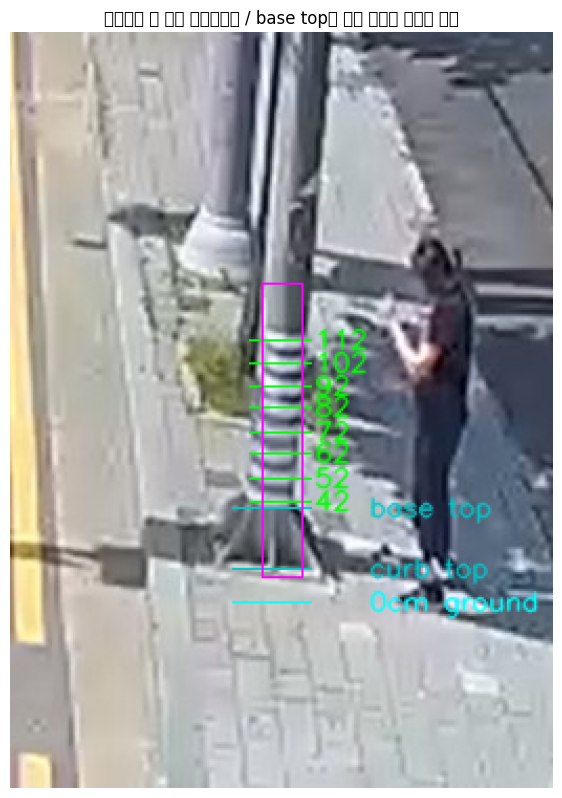

In [8]:
vis = draw_scale(ref, calib)
crop = crop_pole(vis, calib, margin=120)
plt.figure(figsize=(7, 11))
plt.imshow(cv2.cvtColor(cv2.resize(crop, None, fx=3, fy=3, interpolation=cv2.INTER_NEAREST),
                        cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("초록선이 흰 띠와 일치하는지 / base top이 밑둥 상단과 맞는지 확인")
plt.show()

초록 눈금이 실제 흰 띠와 어긋나면 아래 중 하나를 조정하세요.

| 증상 | 조치 |
|---|---|
| 띠를 너무 적게 찾음 | `detect_bands(..., min_prom=8)` 로 낮추기 |
| 가짜 띠가 섞임 | `POLE_ROI`를 띠 구간만 남기도록 축소 |
| 눈금이 통째로 10cm씩 어긋남 | 최하단 띠가 첫 번째 띠(41.5cm)가 맞는지 확인 — 아래 셀로 수동 보정 |

In [9]:
# 최하단 검출 띠가 규격상 몇 번째인지 어긋났을 때만 사용
SHIFT_BANDS = 0   # +1: 실제로는 한 칸 위쪽 띠였다 / -1: 한 칸 아래

if SHIFT_BANDS:
    calib["band_cm"] = [c + SHIFT_BANDS * (SPEC["band_cm"] + SPEC["gap_cm"])
                        for c in calib["band_cm"]]
    coef = np.polyfit(calib["band_y"], calib["band_cm"], calib["deg"])
    calib["coef"] = [float(v) for v in coef]
    calib["max_residual_cm"] = float(
        np.max(np.abs(np.polyval(coef, calib["band_y"]) - np.array(calib["band_cm"]))))
    print("보정 완료 | 도로면 y =", round(cm_to_y(calib, 0), 1))
else:
    print("보정 없음")

Path(CALIB_OUT).parent.mkdir(parents=True, exist_ok=True)
Path(CALIB_OUT).write_text(json.dumps(calib, ensure_ascii=False, indent=2), encoding="utf-8")
print("캘리브레이션 저장:", CALIB_OUT)

보정 없음
캘리브레이션 저장: C:\Project\PythonProject\PyTorch001\data\pole_calib.json


## 5. 다른 프레임으로 캘리브레이션 이전

같은 CCTV라도 해상도나 화각이 미세하게 다르면 픽셀 좌표가 어긋납니다.
ORB 특징점 + RANSAC 호모그래피로 레퍼런스 → 침수 프레임 좌표 변환을 구해 눈금을 옮깁니다.

inlier가 **50개 미만**이면 정합 실패로 보고, 침수 프레임에서 직접 ROI를 잡으세요.

In [10]:
# ──────────────────────────────────────────────────────────────
# 다른 프레임으로 캘리브레이션 이전 (해상도/프레이밍이 달라도 OK)
# ──────────────────────────────────────────────────────────────
def align_homography(ref_img, tgt_img, nfeatures=5000, ratio=0.75):
    g1 = cv2.cvtColor(ref_img, cv2.COLOR_BGR2GRAY)
    g2 = cv2.cvtColor(tgt_img, cv2.COLOR_BGR2GRAY)
    orb = cv2.ORB_create(nfeatures)
    k1, d1 = orb.detectAndCompute(g1, None)
    k2, d2 = orb.detectAndCompute(g2, None)
    if d1 is None or d2 is None:
        return None, 0
    bf = cv2.BFMatcher(cv2.NORM_HAMMING)
    good = [a for a, b in bf.knnMatch(d1, d2, k=2) if a.distance < ratio * b.distance]
    if len(good) < 12:
        return None, len(good)
    src = np.float32([k1[g.queryIdx].pt for g in good]).reshape(-1, 1, 2)
    dst = np.float32([k2[g.trainIdx].pt for g in good]).reshape(-1, 1, 2)
    H, mask = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
    return H, int(mask.sum()) if mask is not None else 0


def warp_calibration(calib, H):
    """레퍼런스 좌표계의 캘리브레이션을 타깃 좌표계로 이전"""
    x1, y1, x2, y2 = calib["roi"]
    xc = (x1 + x2) / 2

    pts = np.float32([[xc, y] for y in calib["band_y"]]).reshape(-1, 1, 2)
    ny = cv2.perspectiveTransform(pts, H).reshape(-1, 2)[:, 1]

    corners = np.float32([[x1, y1], [x2, y1], [x1, y2], [x2, y2]]).reshape(-1, 1, 2)
    c = cv2.perspectiveTransform(corners, H).reshape(-1, 2)
    nroi = [int(c[:, 0].min()), int(c[:, 1].min()), int(c[:, 0].max()), int(c[:, 1].max())]

    cms = calib["band_cm"]
    deg = min(calib["deg"], len(ny) - 1)
    coef = np.polyfit(ny, cms, deg)

    out = dict(calib)
    out.update({
        "roi": nroi,
        "band_y": [float(v) for v in ny],
        "coef": [float(v) for v in coef],
        "px_per_cm": float(abs(ny[0] - ny[-1]) / (cms[-1] - cms[0])),
        "warped": True,
    })
    return out

## 6. 수심 계산 로직

In [11]:
# ──────────────────────────────────────────────────────────────
# 수심 계산
# ──────────────────────────────────────────────────────────────
def water_line_at_pole(mask, roi, robust_pct=5):
    """
    기둥 ROI의 x구간에서 수면 최상단 y.
    robust_pct: 상위 p% 지점을 사용해 물튀김/노이즈에 강건하게
    """
    x1, _, x2, _ = roi
    h, w = mask.shape
    x1 = max(0, min(x1, w - 1))
    x2 = max(x1 + 1, min(x2, w))
    col = mask[:, x1:x2]
    ys = np.where(col.any(axis=1))[0]
    if len(ys) == 0:
        return None
    return float(np.percentile(ys, robust_pct))


def measure_depth(calib, water_y):
    if water_y is None:
        return {"depth_cm": 0.0, "water_y": None, "status": "no_water"}
    depth = y_to_cm(calib, water_y)
    ys = calib["band_y"]
    status = "ok"
    if water_y < min(ys):
        status = "extrapolated_above"   # 최상단 띠보다 위 → 외삽
    elif water_y > max(ys):
        status = "below_first_band"     # 첫 띠보다 아래 (밑둥/연석 구간)
    return {"depth_cm": round(max(depth, 0.0), 1),
            "water_y": round(water_y, 1), "status": status}

`status` 값의 의미

| status | 뜻 |
|---|---|
| `ok` | 띠 구간 안 — 가장 신뢰도 높음 |
| `below_first_band` | 첫 띠(39cm)보다 아래. 밑둥·연석 구간이라 외삽이며 오차가 큼 |
| `extrapolated_above` | 최상단 띠보다 위. 측정 범위 초과 — **참고값**으로만 사용 |
| `no_water` | 기둥 구간에서 물 미검출 |

## 7. 수면 모델 로드

In [12]:
import torch
from ultralytics import YOLO

WEIGHTS = r"C:\Project\PythonProject\PyTorch001\runs_water_v3\exported\water_seg_v3_best.pt"
CONF    = 0.25     # 평가 노트북에서 찾은 최적값으로 교체
IMGSZ   = 640

if not Path(WEIGHTS).exists():
    cands = sorted(Path(r"C:\Project\PythonProject\PyTorch001").rglob("weights/best.pt"),
                   key=lambda p: p.stat().st_mtime, reverse=True)
    assert cands, "가중치를 찾지 못했습니다."
    WEIGHTS = str(cands[0]); print("[자동탐색]", WEIGHTS)

DEV = 0 if torch.cuda.is_available() else "cpu"
model = YOLO(WEIGHTS)
print("모델 로드:", WEIGHTS, "| 클래스", model.names)


def water_mask(bgr, conf=CONF):
    h, w = bgr.shape[:2]
    r = model.predict(source=bgr, conf=conf, imgsz=IMGSZ, device=DEV, verbose=False)[0]
    m = np.zeros((h, w), np.uint8)
    if r.masks is not None:
        for mm in r.masks.data.cpu().numpy():
            mm = cv2.resize(mm.astype(np.float32), (w, h), interpolation=cv2.INTER_LINEAR)
            m |= (mm > 0.5).astype(np.uint8)
    return m

모델 로드: C:\Project\PythonProject\PyTorch001\runs_water_v3\exported\water_seg_v3_best.pt | 클래스 {0: 'water'}


## 8. 전체 파이프라인 — 이미지 한 장 → 침수 깊이(cm)

정합 성공 (inliers=832)


C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_16340\972599500.py:38: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_16340\972599500.py:38: UserWarning: Glyph 46181 (\N{HANGUL SYLLABLE DUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_16340\972599500.py:38: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_16340\972599500.py:38: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()


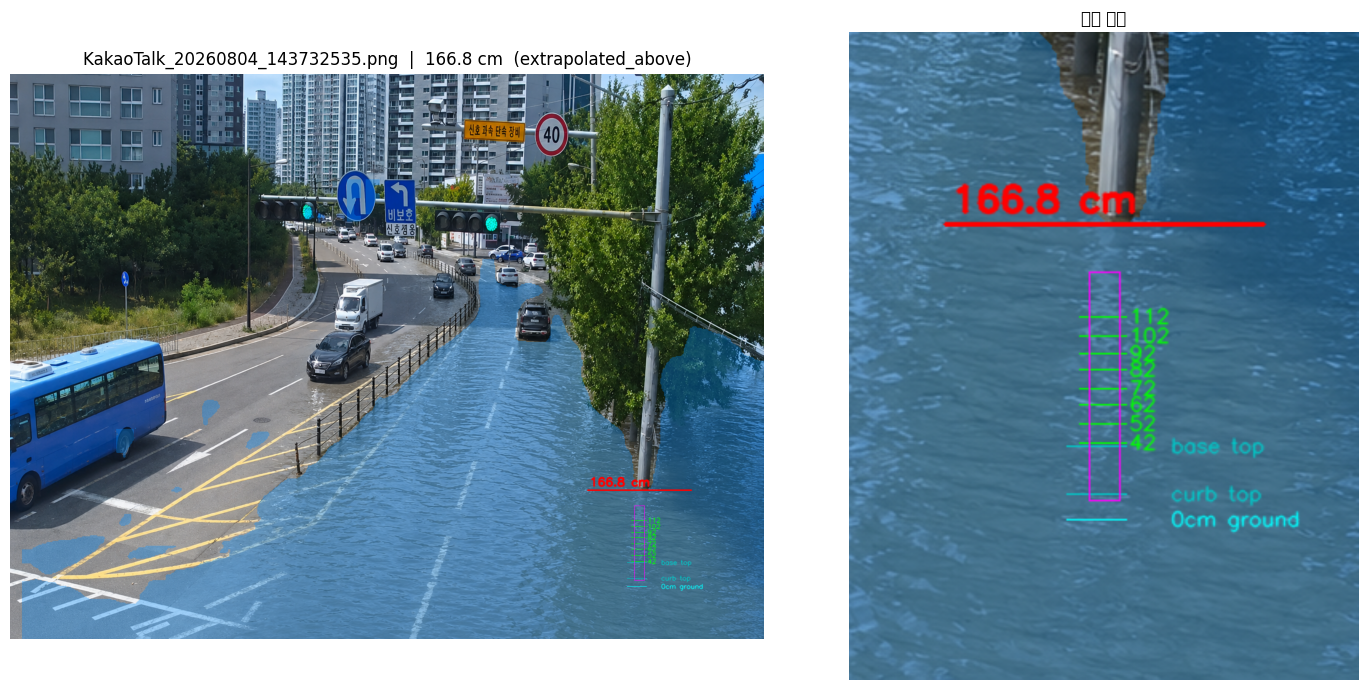

{
  "depth_cm": 166.8,
  "water_y": 800.0,
  "status": "extrapolated_above",
  "file": "KakaoTalk_20260804_143732535.png",
  "ground_y": 985.4
}


In [27]:
def measure_image(img_path, calib_ref, ref_img=None, conf=CONF,
                  align=True, show=True, robust_pct=5):
    """
    img_path  : 침수 프레임
    calib_ref : 레퍼런스 프레임 기준 캘리브레이션
    ref_img   : 레퍼런스 이미지(정합용). align=False면 불필요
    """
    bgr = cv2.imread(str(img_path))
    assert bgr is not None, f"읽기 실패: {img_path}"

    cal = calib_ref
    if align and ref_img is not None and bgr.shape[:2] != tuple(calib_ref["img_shape"]):
        H, inl = align_homography(ref_img, bgr)
        if H is None or inl < 50:
            print(f"[경고] 정합 불안정 (inliers={inl}) — 레퍼런스 좌표를 그대로 사용합니다")
        else:
            cal = warp_calibration(calib_ref, H)
            print(f"정합 성공 (inliers={inl})")

    mask = water_mask(bgr, conf)
    wy = water_line_at_pole(mask, cal["roi"], robust_pct=robust_pct)
    res = measure_depth(cal, wy)
    res["file"] = Path(img_path).name
    res["ground_y"] = round(cm_to_y(cal, 0), 1)

    if show:
        vis = bgr.copy()
        idx = mask == 1
        vis[idx] = (0.35 * np.array([255, 140, 0]) + 0.65 * vis[idx]).astype(np.uint8)
        vis = draw_scale(vis, cal, water_y=wy, depth=res["depth_cm"])

        fig, ax = plt.subplots(1, 2, figsize=(15, 7))
        ax[0].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)); ax[0].axis("off")
        ax[0].set_title(f"{res['file']}  |  {res['depth_cm']} cm  ({res['status']})")
        c = crop_pole(vis, cal, margin=150)
        ax[1].imshow(cv2.cvtColor(cv2.resize(c, None, fx=2.2, fy=2.2), cv2.COLOR_BGR2RGB))
        ax[1].axis("off"); ax[1].set_title("기둥 확대")
        plt.tight_layout(); plt.show()

    return res


TARGET = r"C:\Users\Win11Pro\Downloads\물이미지\KakaoTalk_20260804_143732535.png"
result = measure_image(TARGET, calib, ref_img=ref)
print(json.dumps(result, ensure_ascii=False, indent=2))

## 9. 침수 단계 매핑

측정된 cm를 프로젝트의 5단계 기준으로 변환합니다.
임계값은 서울연구원 림 기준에 맞춰 조정하세요.

In [17]:
DEPTH_LEVELS = [(0,  10,  0, "정상"),
                (10, 20,  1, "주의 — 노면 침수 시작"),
                (20, 30,  2, "경계 — 타이어 하단"),
                (30, 45,  3, "심각 — 휠 림 도달"),
                (45, 999, 4, "위험 — 통행 불가")]

def depth_to_level(cm):
    for lo, hi, lv, desc in DEPTH_LEVELS:
        if lo <= cm < hi:
            return lv, desc
    return 4, "위험"

lv, desc = depth_to_level(result["depth_cm"])
print(f"침수 깊이 {result['depth_cm']} cm  ->  Level {lv} ({desc})")
if result["status"] != "ok":
    print(f"[주의] status={result['status']} — 띠 구간을 벗어난 외삽값입니다")

침수 깊이 166.8 cm  ->  Level 4 (위험 — 통행 불가)
[주의] status=extrapolated_above — 띠 구간을 벗어난 외삽값입니다


## 10. 폴더/영상 일괄 처리

In [14]:
def measure_folder(src_dir, calib_ref, ref_img, conf=CONF, out_csv=None):
    import csv as _csv
    files = sorted([f for f in Path(src_dir).iterdir()
                    if f.suffix.lower() in (".jpg", ".jpeg", ".png")])
    rows = []
    for f in files:
        try:
            r = measure_image(f, calib_ref, ref_img, conf=conf, show=False)
            lv, desc = depth_to_level(r["depth_cm"])
            rows.append({"file": r["file"], "depth_cm": r["depth_cm"],
                         "level": lv, "status": r["status"], "water_y": r["water_y"]})
        except Exception as e:
            print(f"[skip] {f.name}: {e}")

    if rows:
        out_csv = out_csv or (Path(src_dir).parent / "pole_depth.csv")
        with open(out_csv, "w", newline="", encoding="utf-8-sig") as fp:
            w = _csv.DictWriter(fp, fieldnames=list(rows[0].keys()))
            w.writeheader(); w.writerows(rows)
        print(f"{len(rows)}장 처리 | CSV: {out_csv}")

        ds = [r["depth_cm"] for r in rows]
        plt.figure(figsize=(9, 4))
        plt.plot(ds, "o-", ms=3)
        plt.ylabel("depth (cm)"); plt.xlabel("frame"); plt.grid(alpha=0.3)
        plt.title("Pole-based water depth"); plt.tight_layout(); plt.show()
    return rows


# rows = measure_folder(r"C:\path\to\flood_frames", calib, ref)

## 11. 정확도에 대한 솔직한 한계

| 요인 | 영향 | 완화 |
|---|---|---|
| 띠 1개 = 약 11px | 1px 오차 ≈ **0.9cm** | 원본 해상도 유지, 다운스케일 금지 |
| 수면 물결·물튀김 | 수면선이 흔들림 | `robust_pct=5` 백분위 사용, 연속 프레임 중앙값 |
| 기둥 위치 ≠ 도로 위치 | 기둥이 낮은 지대면 도로 수심과 다름 | 도로면 기준 오프셋을 별도 보정 |
| 띠 구간(39~112cm) 밖 | 외삽 → 오차 급증 | `status`가 `ok`인 구간만 정량 보고 |
| 야간·역광 | 밝기 프로파일 붕괴 | 주간 프레임으로 캘리브레이션 후 좌표 고정 재사용 |

**캘리브레이션은 카메라가 움직이지 않는 한 1회만 하면 됩니다.**
`pole_calib.json`을 저장해두고 이후 프레임에서는 불러 쓰세요.

In [15]:
# 저장된 캘리브레이션 재사용
loaded = json.loads(Path(CALIB_OUT).read_text(encoding="utf-8"))
print("불러온 캘리브레이션")
print(f"  ROI        : {loaded['roi']}")
print(f"  띠 개수    : {len(loaded['band_y'])}")
print(f"  px/cm      : {loaded['px_per_cm']:.3f}")
print(f"  측정 가능 범위 : {min(loaded['band_cm']):.1f} ~ {max(loaded['band_cm']):.1f} cm")
print(f"  최대 잔차  : {loaded['max_residual_cm']:.2f} cm")

불러온 캘리브레이션
  ROI        : [1188, 825, 1207, 965]
  띠 개수    : 8
  px/cm      : 1.100
  측정 가능 범위 : 41.5 ~ 111.5 cm
  최대 잔차  : 0.51 cm
